In [1]:
import sys
from pathlib import Path

sys.path.insert(
    0,
    str(Path.home() / "GitHub" / "MIML" / "src")
)
output_path = str(Path.home() / "GitHub" / "MIML" / "src" / "miml" / "tutorial")

from miml.data import load_dataset

import miml

print(miml.__file__)

/home/juanjo/GitHub/MIML/src/miml/__init__.py


In [2]:
%pip install numpy pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    hamming_loss,
)

# Add the project source directory to Python's path.
sys.path.insert(
    0,
    str(Path.home() / "GitHub" / "MIML" / "src"),
)

from miml.data import load_dataset

from miml.classifier.miml.lazy.miml_br_knn import MIMLBRkNN
from miml.classifier.miml.lazy.miml_dgc import MIMLDGC
from miml.classifier.miml.lazy.miml_map_knn import MIMLMAPkNN
from miml.classifier.miml.lazy.miml_knn import MIMLkNN

from miml.core.average_hausdorff import AverageHausdorff
from miml.core.maximal_hausdorff import MaximalHausdorff
from miml.core.minimal_hausdorff import MinimalHausdorff

In [4]:
birds = load_dataset(
    "miml_birds.arff",
    from_library=True,
)

birds_train, birds_test = birds.split_dataset(
    train_percentage=0.8,
    seed=7,
)


# text = load_dataset(
#     "miml_text_data.arff",
#     from_library=True,
# )

# text_train, text_test = text.split_dataset(
#     train_percentage=0.8,
#     seed=7,
# )


# image = load_dataset(
#     "miml_image_data.arff",
#     from_library=True,
# )

# image_train, image_test = image.split_dataset(
#     train_percentage=0.8,
#     seed=7,
# )

datasets = {
    "birds": (birds_train, birds_test),
    # "text": (text_train, text_test),
    # "image": (image_train, image_test),
}

In [5]:
algorithms = {
    "MIMLBRkNN": MIMLBRkNN,
    "MIMLDGC": MIMLDGC,
    "MIMLMAPkNN": MIMLMAPkNN,
    "MIMLkNN": MIMLkNN,
}


distances = {
    "AverageHausdorff": AverageHausdorff(),
    "MaximalHausdorff": MaximalHausdorff(),
    "MinimalHausdorff": MinimalHausdorff(),
}

In [6]:
experiment_table = pd.DataFrame(
    [
        {
            "Algorithm": algorithm_name,
            "Distance": distance_name,
        }
        for algorithm_name in algorithms
        for distance_name in distances
    ]
)

experiment_table

,Algorithm,Distance
0,MIMLBRkNN,AverageHausdorff
1,MIMLBRkNN,MaximalHausdorff
2,MIMLBRkNN,MinimalHausdorff
3,MIMLDGC,AverageHausdorff
4,MIMLDGC,MaximalHausdorff
5,MIMLDGC,MinimalHausdorff
6,MIMLMAPkNN,AverageHausdorff
7,MIMLMAPkNN,MaximalHausdorff
8,MIMLMAPkNN,MinimalHausdorff
9,MIMLkNN,AverageHausdorff


In [7]:
def create_classifiers(metric):
    return {
        "MIMLBRkNN": MIMLBRkNN(
            metric=metric,
            num_of_neighbours=10,
        ),
        "MIMLDGC": MIMLDGC(
            metric=metric,
            num_of_neighbours=10,
        ),
        "MIMLMAPkNN": MIMLMAPkNN(
            metric=metric,
            num_of_neighbours=10,
        ),
        "MIMLkNN": MIMLkNN(
            metric=metric,
            num_references=10,
            num_citers=10,
        ),
    }

In [8]:
def get_true_labels(dataset):
    bags = list(dataset.data.values())

    labels = []

    for bag in bags:
        bag_labels = bag.get_labels()

        if bag_labels.ndim == 2:
            bag_labels = np.max(bag_labels, axis=0)

        labels.append(bag_labels)

    return np.asarray(labels, dtype=int)

In [9]:
def multilabel_accuracy(y_true, y_pred):
    """Calculate accuracy over all individual label decisions."""

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.mean(y_true == y_pred)

In [10]:
def calculate_metrics(y_true, y_pred):
    return {
        "F1 Macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "F1 Micro": f1_score(
            y_true,
            y_pred,
            average="micro",
            zero_division=0,
        ),
        "Subset Accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "Hamming Loss": hamming_loss(
            y_true,
            y_pred,
        ),
        "Accuracy": multilabel_accuracy(
            y_true,
            y_pred,
        ),
    }

In [11]:
results = []

for dataset_name, (dataset_train, dataset_test) in datasets.items():

    y_true = get_true_labels(dataset_test)

    for distance_name, distance in distances.items():

        classifiers = create_classifiers(distance)

        for classifier_name, classifier in classifiers.items():

            classifier.build(dataset_train)

            y_pred = classifier.evaluate(dataset_test)

            metrics = calculate_metrics(
                y_true,
                y_pred,
            )

            results.append({
                "Dataset": dataset_name,
                "Algorithm": classifier_name,
                "Distance": distance_name,
                **metrics,
            })

In [12]:
results_df = pd.DataFrame(results)

results_df

,Dataset,Algorithm,Distance,F1 Macro,F1 Micro,Subset Accuracy,Hamming Loss,Accuracy
0,birds,MIMLBRkNN,AverageHausdorff,0.043499,0.164179,0.058824,0.115583,0.884417
1,birds,MIMLDGC,AverageHausdorff,0.048543,0.174603,0.058824,0.107327,0.892673
2,birds,MIMLMAPkNN,AverageHausdorff,0.016869,0.038095,0.000000,0.104231,0.895769
3,birds,MIMLkNN,AverageHausdorff,0.019737,0.056075,0.000000,0.104231,0.895769
4,birds,MIMLBRkNN,MaximalHausdorff,0.055528,0.213836,0.078431,0.128999,0.871001
5,birds,MIMLDGC,MaximalHausdorff,0.074417,0.214765,0.098039,0.120743,0.879257
6,birds,MIMLMAPkNN,MaximalHausdorff,0.005540,0.019231,0.019608,0.105263,0.894737
7,birds,MIMLkNN,MaximalHausdorff,0.008772,0.019417,0.019608,0.104231,0.895769
8,birds,MIMLBRkNN,MinimalHausdorff,0.101590,0.260274,0.117647,0.111455,0.888545
9,birds,MIMLDGC,MinimalHausdorff,0.124115,0.278146,0.117647,0.112487,0.887513


In [13]:
results_df.round(4)

,Dataset,Algorithm,Distance,F1 Macro,F1 Micro,Subset Accuracy,Hamming Loss,Accuracy
0,birds,MIMLBRkNN,AverageHausdorff,0.0435,0.1642,0.0588,0.1156,0.8844
1,birds,MIMLDGC,AverageHausdorff,0.0485,0.1746,0.0588,0.1073,0.8927
2,birds,MIMLMAPkNN,AverageHausdorff,0.0169,0.0381,0.0000,0.1042,0.8958
3,birds,MIMLkNN,AverageHausdorff,0.0197,0.0561,0.0000,0.1042,0.8958
4,birds,MIMLBRkNN,MaximalHausdorff,0.0555,0.2138,0.0784,0.1290,0.8710
5,birds,MIMLDGC,MaximalHausdorff,0.0744,0.2148,0.0980,0.1207,0.8793
6,birds,MIMLMAPkNN,MaximalHausdorff,0.0055,0.0192,0.0196,0.1053,0.8947
7,birds,MIMLkNN,MaximalHausdorff,0.0088,0.0194,0.0196,0.1042,0.8958
8,birds,MIMLBRkNN,MinimalHausdorff,0.1016,0.2603,0.1176,0.1115,0.8885
9,birds,MIMLDGC,MinimalHausdorff,0.1241,0.2781,0.1176,0.1125,0.8875


In [14]:
results_path = Path(output_path) / "miml_experiments.csv"

results_df.to_csv(
    results_path,
    index=False,
)

print(f"Results saved to: {results_path}")

Results saved to: /home/juanjo/GitHub/MIML/src/miml/tutorial/miml_experiments.csv


In [15]:
f1_macro_table = results_df.pivot_table(
    index=["Algorithm", "Distance"],
    columns="Dataset",
    values="F1 Macro",
)

f1_macro_table.round(4)

Dataset                       birds
Algorithm  Distance                
MIMLBRkNN  AverageHausdorff  0.0435
           MaximalHausdorff  0.0555
           MinimalHausdorff  0.1016
MIMLDGC    AverageHausdorff  0.0485
           MaximalHausdorff  0.0744
           MinimalHausdorff  0.1241
MIMLMAPkNN AverageHausdorff  0.0169
           MaximalHausdorff  0.0055
           MinimalHausdorff  0.0485
MIMLkNN    AverageHausdorff  0.0197
           MaximalHausdorff  0.0088
           MinimalHausdorff  0.0241

In [16]:
algorithm_f1 = results_df.groupby(
    "Algorithm"
)[
    [
        "F1 Macro",
        "F1 Micro",
        "Subset Accuracy",
        "Hamming Loss",
        "Accuracy",
    ]
].mean()

algorithm_f1.round(4)

,F1 Macro,F1 Micro,Subset Accuracy,Hamming Loss,Accuracy
Algorithm,,,,,
MIMLBRkNN,0.0669,0.2128,0.0850,0.1187,0.8813
MIMLDGC,0.0824,0.2225,0.0915,0.1135,0.8865
MIMLMAPkNN,0.0236,0.0542,0.0131,0.1049,0.8951
MIMLkNN,0.0175,0.0496,0.0261,0.1042,0.8958


In [17]:
distance_results = results_df.groupby(
    "Distance"
)[
    [
        "F1 Macro",
        "F1 Micro",
        "Subset Accuracy",
        "Hamming Loss",
        "Accuracy",
    ]
].mean()

distance_results.round(4)

,F1 Macro,F1 Micro,Subset Accuracy,Hamming Loss,Accuracy
Distance,,,,,
AverageHausdorff,0.0322,0.1082,0.0294,0.1078,0.8922
MaximalHausdorff,0.0361,0.1168,0.0539,0.1148,0.8852
MinimalHausdorff,0.0746,0.1793,0.0784,0.1084,0.8916


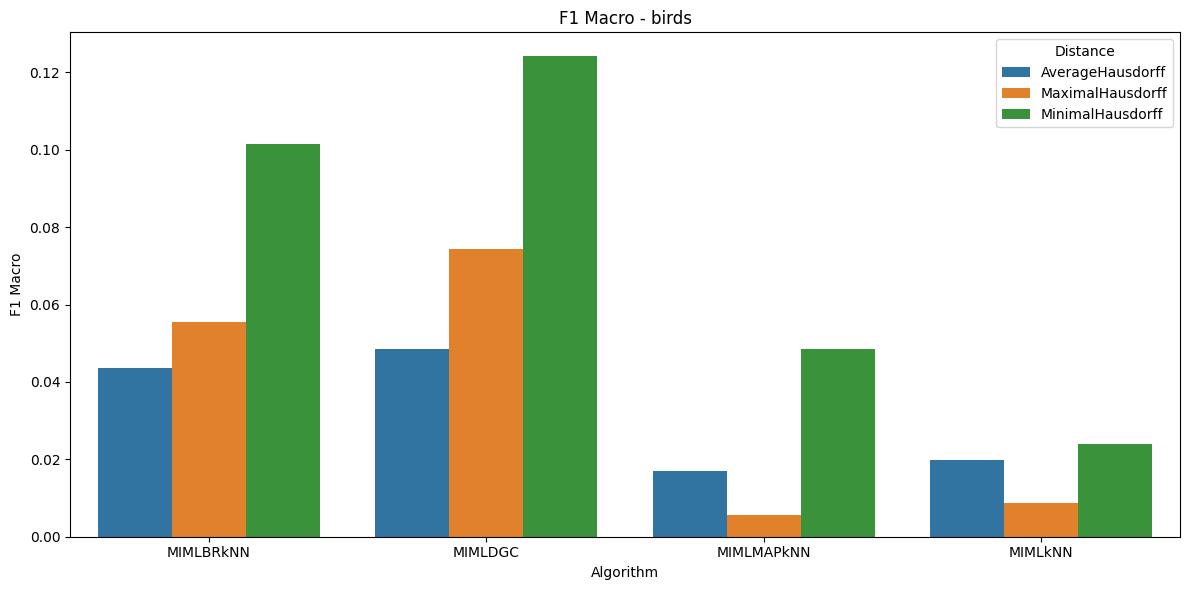

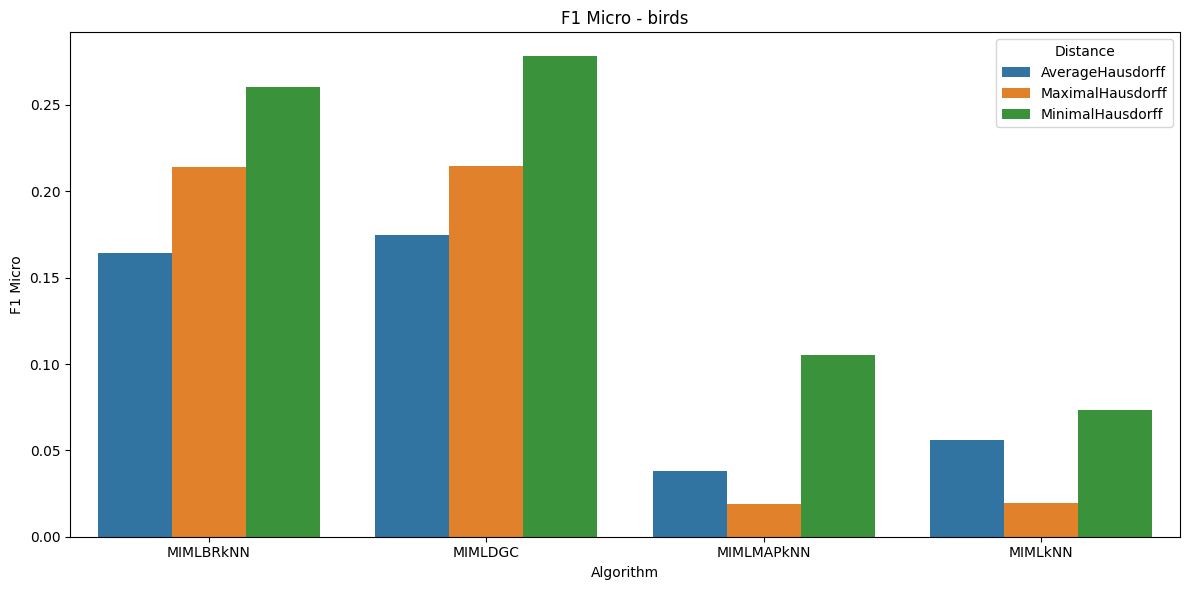

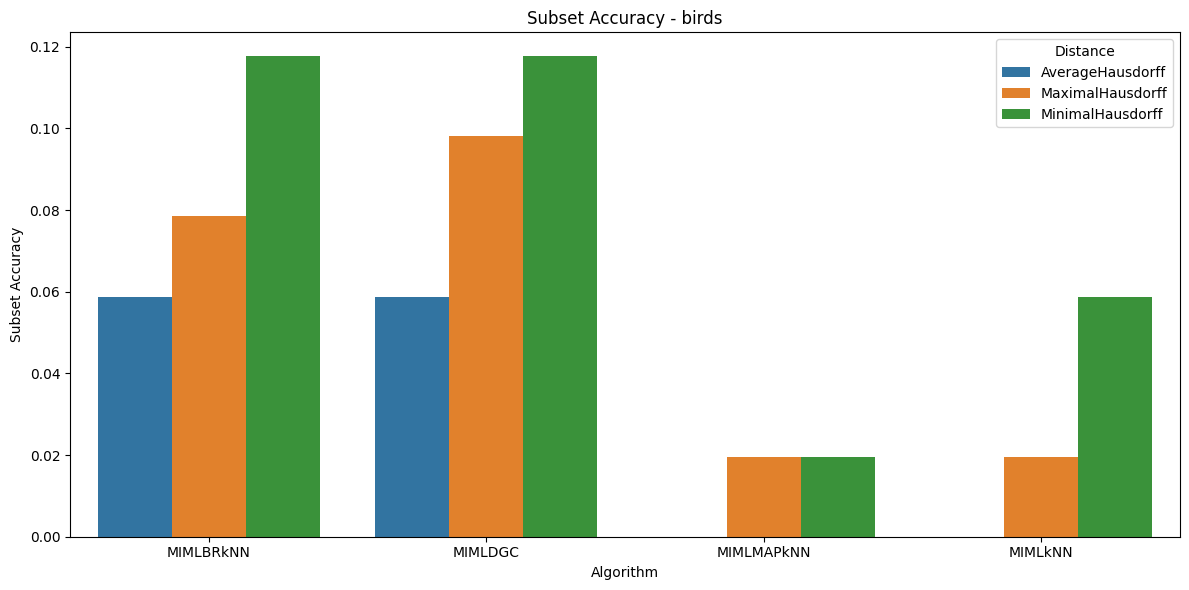

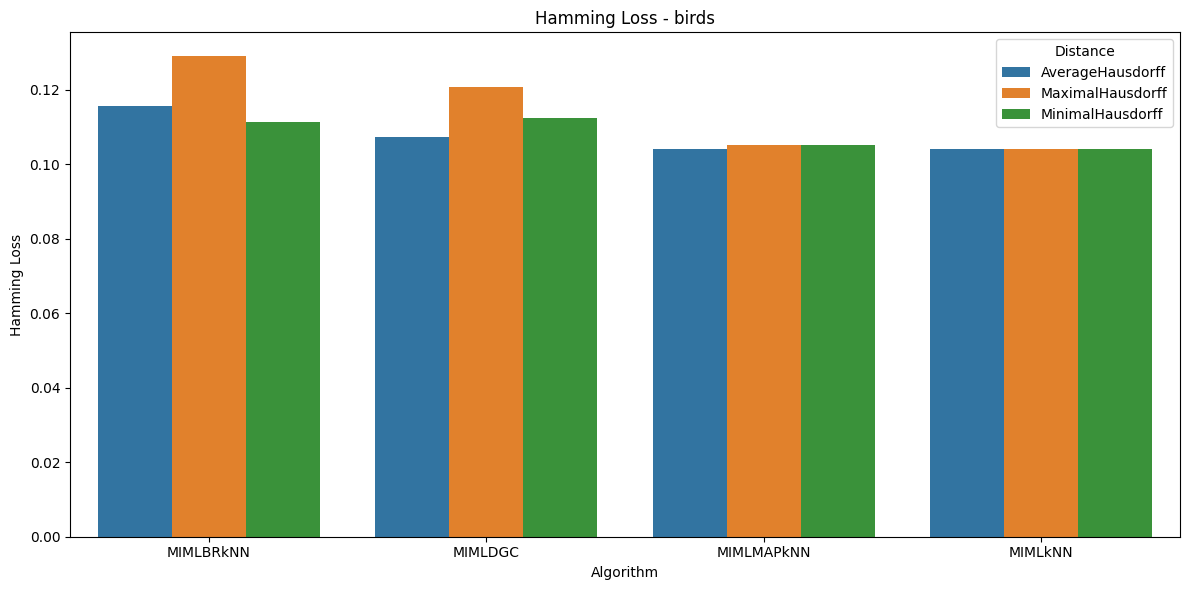

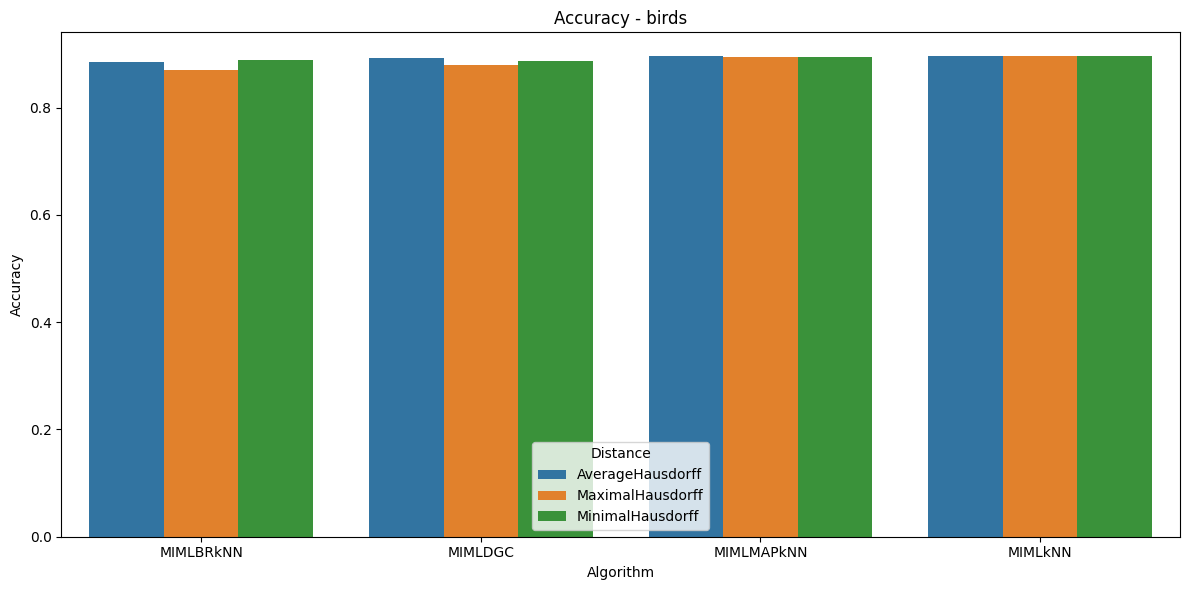

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metric(dataframe, metric, dataset_name):

    data = dataframe[
        dataframe["Dataset"] == dataset_name
    ]

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=data,
        x="Algorithm",
        y=metric,
        hue="Distance",
    )

    plt.title(f"{metric} - {dataset_name}")
    plt.xlabel("Algorithm")
    plt.ylabel(metric)

    plt.tight_layout()
    plt.show()


metrics_to_plot = [
    "F1 Macro",
    "F1 Micro",
    "Subset Accuracy",
    "Hamming Loss",
    "Accuracy",
]

for metric in metrics_to_plot:
    plot_metric(
        results_df,
        metric,
        "birds",
    )